# PTB-XL ECG Dataset — Exploratory Data Analysis & Cleaning

**Dataset:** PTB-XL — 21,837 clinical 12-lead ECGs, 10 s at 500 Hz  
**Source:** https://physionet.org/content/ptb-xl/1.0.3/  
**Goal:** Understand the data structure, detect quality issues, and prepare clean splits for training.

| Class | Label | Description |
|-------|-------|-------------|
| NORM  | 0 | Normal ECG |
| MI    | 1 | Myocardial Infarction |
| STTC  | 2 | ST/T Change |
| CD    | 3 | Conduction Disturbance |
| HYP   | 4 | Hypertrophy |

## 1. Setup & Imports

In [27]:
import ast
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import wfdb
from scipy.signal import butter, filtfilt
from scipy.stats import kurtosis

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")

# ── Paths ────────────────────────────────────────────────────────────────────
RAW_DIR  = Path("../../dataset/raw/ptb-xl")   # adjust if needed
PROC_DIR = Path("../../dataset/processed")

META_CSV = RAW_DIR / "ptbxl_database.csv"
SCP_CSV  = RAW_DIR / "scp_statements.csv"

FS = 100          # sampling rate to use (100 Hz records)
LEAD_NAMES = ["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"]

SUPERCLASS_LABELS = {"NORM": 0, "MI": 1, "STTC": 2, "CD": 3, "HYP": 4}
LABEL_NAMES = {v: k for k, v in SUPERCLASS_LABELS.items()}

print(f"RAW_DIR  : {RAW_DIR.resolve()}")
print(f"PROC_DIR : {PROC_DIR.resolve()}")
print(f"PTB-XL metadata exists: {META_CSV.exists()}")

RAW_DIR  : /Users/ayoub/work/MS-DS_ML_Projects/IOT/projet-embarque/dataset/raw/ptb-xl
PROC_DIR : /Users/ayoub/work/MS-DS_ML_Projects/IOT/projet-embarque/dataset/processed
PTB-XL metadata exists: True


## 2. Dataset Structure Verification

In [17]:
# Walk raw directory
if RAW_DIR.exists():
    dat_files = list(RAW_DIR.rglob("*.dat"))
    hea_files = list(RAW_DIR.rglob("*.hea"))
    print(f"Raw directory   : {RAW_DIR}")
    print(f"  .dat records  : {len(dat_files)}")
    print(f"  .hea headers  : {len(hea_files)}")
else:
    print(f"[!] Raw directory not found: {RAW_DIR}")
    print("    Run dataset/download.sh first.")

# Walk processed directory
print()
if PROC_DIR.exists():
    for split in ("train", "val", "test"):
        split_dir = PROC_DIR / split
        x_file = split_dir / "X.npy"
        y_file = split_dir / "y.npy"
        if x_file.exists():
            X = np.load(x_file, mmap_mode="r")
            y = np.load(y_file, mmap_mode="r")
            print(f"processed/{split}: X={X.shape}  y={y.shape}")
        else:
            print(f"processed/{split}: [not yet created — run preprocess.py]")
else:
    print("[!] Processed directory not found — run preprocess.py first.")

Raw directory   : ../../dataset/raw/ptb-xl
  .dat records  : 43674
  .hea headers  : 43674

processed/train: X=(15000, 1000, 12)  y=(15000,)
processed/val: X=(3215, 1000, 12)  y=(3215,)
processed/test: [not yet created — run preprocess.py]


## 3. Load PTB-XL Records

In [18]:
def extract_superclass(scp_codes_str: str, agg_df: pd.DataFrame) -> str | None:
    """Map SCP codes to one of the 5 diagnostic superclasses."""
    try:
        codes = ast.literal_eval(scp_codes_str)
    except Exception:
        return None
    # Keep only diagnostic SCP codes (diagnostic == 1)
    diag = {k: v for k, v in codes.items()
            if k in agg_df.index and agg_df.loc[k, "diagnostic"] == 1}
    if not diag:
        return None
    best = max(diag, key=diag.get)          # highest-confidence code
    sc = agg_df.loc[best, "diagnostic_class"]  # ← correct column name
    return sc if sc in SUPERCLASS_LABELS else None


# Load metadata & SCP statements
if META_CSV.exists():
    meta_df = pd.read_csv(META_CSV, index_col="ecg_id")
    agg_df  = pd.read_csv(SCP_CSV,  index_col=0)

    meta_df["superclass"] = meta_df["scp_codes"].apply(
        lambda s: extract_superclass(s, agg_df)
    )
    meta_df["label"]      = meta_df["superclass"].map(SUPERCLASS_LABELS)
    meta_df["label_name"] = meta_df["label"].map(LABEL_NAMES)

    labelled   = meta_df.dropna(subset=["superclass"])
    unlabelled = len(meta_df) - len(labelled)

    print(f"Total records             : {len(meta_df):>6,}")
    print(f"Labelled (has superclass) : {len(labelled):>6,}")
    print(f"Unlabelled / ambiguous    : {unlabelled:>6,}")
    print()
    print(labelled[["age", "sex", "superclass", "label", "recording_date"]].head())
else:
    print("[!] metadata CSV not found — download the dataset first.")


Total records             : 21,837
Labelled (has superclass) : 21,430
Unlabelled / ambiguous    :    407

         age  sex superclass  label       recording_date
ecg_id                                                  
1       56.0    1       NORM    0.0  1984-11-09 09:17:34
2       19.0    0       NORM    0.0  1984-11-14 12:55:37
3       37.0    1       NORM    0.0  1984-11-15 12:49:10
4       24.0    0       NORM    0.0  1984-11-15 13:44:57
5       19.0    1       NORM    0.0  1984-11-17 10:43:15


## 4. Signal Quality & Missing Value Analysis

=== Metadata Quality Flags ===
  baseline_drift           : 1,607  (7.4%)
  static_noise             : 3,262  (14.9%)
  burst_noise              :   613  (2.8%)
  electrodes_problems      :    30  (0.1%)
  pacemaker                :   293  (1.3%)

Records with ≥1 quality flag: 5,254  (24.1% of 21,837)
Labelled records with ≥1 flag: 4,935  (23.0%)



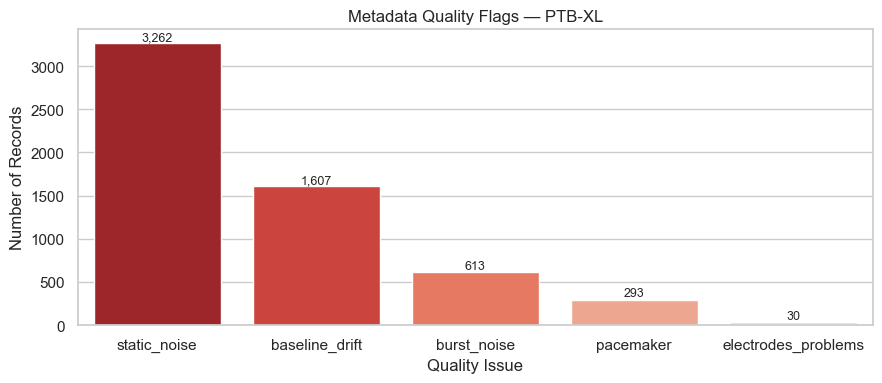

=== Signal-Level Quality Check (first 200 labelled records) ===
  Records inspected  : 200
  Records with NaN   : 0
  Records with ≥1 flat lead: 0
  Mean SNR (proxy)   : 0.0217

       n_flat  mean_snr
count   200.0  200.0000
mean      0.0    0.0217
std       0.0    0.0099
min       0.0    0.0033
25%       0.0    0.0142
50%       0.0    0.0204
75%       0.0    0.0276
max       0.0    0.0551


In [19]:
# ── A. Metadata quality flags (annotated by cardiologists) ──────────────────
# PTB-XL contains per-recording quality annotation columns:
#   baseline_drift | static_noise | burst_noise | electrodes_problems | pacemaker
QUALITY_FLAGS = ["baseline_drift", "static_noise", "burst_noise",
                 "electrodes_problems", "pacemaker"]

if META_CSV.exists():
    flag_summary = {}
    for flag in QUALITY_FLAGS:
        if flag in meta_df.columns:
            n_flagged = (meta_df[flag].notna() & (meta_df[flag] != "")).sum()
            flag_summary[flag] = int(n_flagged)
        else:
            flag_summary[flag] = "column missing"

    print("=== Metadata Quality Flags ===")
    for flag, val in flag_summary.items():
        if isinstance(val, int):
            pct = 100 * val / len(meta_df)
            print(f"  {flag:<25}: {val:>5,}  ({pct:.1f}%)")
        else:
            print(f"  {flag:<25}: {val}")

    # Records marked bad on ≥1 quality flag
    flag_cols = [f for f in QUALITY_FLAGS if f in meta_df.columns]
    any_flag = meta_df[flag_cols].apply(
        lambda col: col.notna() & (col != ""), axis=0
    ).any(axis=1)
    print(f"\nRecords with ≥1 quality flag: {any_flag.sum():,}  "
          f"({100*any_flag.mean():.1f}% of {len(meta_df):,})")

    # breakdown within labelled set
    labelled_flag = any_flag.loc[labelled.index]
    print(f"Labelled records with ≥1 flag: {labelled_flag.sum():,}  "
          f"({100*labelled_flag.mean():.1f}%)")
    print()

    # Plot flag distribution
    flag_counts = pd.Series(
        {f: int(meta_df[f].notna().sum() if f in meta_df.columns else 0)
         for f in QUALITY_FLAGS}
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(9, 4))
    sns.barplot(x=flag_counts.index, y=flag_counts.values,
                palette="Reds_r", ax=ax)
    ax.set_title("Metadata Quality Flags — PTB-XL")
    ax.set_ylabel("Number of Records")
    ax.set_xlabel("Quality Issue")
    for bar in ax.patches:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 5,
                f"{int(bar.get_height()):,}",
                ha="center", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.savefig("quality_flags.png", dpi=120, bbox_inches="tight")
    plt.show()


# ── B. Signal-level quality check on a sample of raw records ─────────────────
def check_signal_quality(signal: np.ndarray, flat_thr: float = 1e-4) -> dict:
    """Compute signal-level quality metrics for one (samples, 12) ECG array."""
    has_nan    = bool(np.isnan(signal).any())
    flat_leads = [i for i in range(signal.shape[1])
                  if signal[:, i].std() < flat_thr]
    snr_per_lead = []
    for i in range(signal.shape[1]):
        lead = signal[:, i]
        snr_per_lead.append(float(np.abs(lead.mean()) / (lead.std() + 1e-8)))
    return {
        "has_nan":  has_nan,
        "n_flat":   len(flat_leads),
        "mean_snr": float(np.mean(snr_per_lead)),
    }


N_SAMPLE = 200
quality_records = []

if META_CSV.exists():
    print(f"=== Signal-Level Quality Check (first {N_SAMPLE} labelled records) ===")
    for ecg_id, row in list(labelled.iterrows())[:N_SAMPLE]:
        try:
            rec_path = str(RAW_DIR / row["filename_lr"])
            rec = wfdb.rdrecord(rec_path)
            sig = rec.p_signal.astype(np.float32)
            q   = check_signal_quality(sig)
        except Exception:
            q = {"has_nan": True, "n_flat": 12, "mean_snr": 0.0}
        quality_records.append(q)

qdf = pd.DataFrame(quality_records)
print(f"  Records inspected  : {len(qdf)}")
print(f"  Records with NaN   : {qdf['has_nan'].sum()}")
print(f"  Records with ≥1 flat lead: {(qdf['n_flat'] > 0).sum()}")
print(f"  Mean SNR (proxy)   : {qdf['mean_snr'].mean():.4f}")
print()
print(qdf[["has_nan", "n_flat", "mean_snr"]].describe().round(4))


## 5. Class Distribution Analysis

Class counts:
superclass
NORM    9260
MI      4199
STTC    3355
CD      3325
HYP     1291

Imbalance ratio (vs majority):
superclass
NORM    1.000
MI      0.453
STTC    0.362
CD      0.359
HYP     0.139


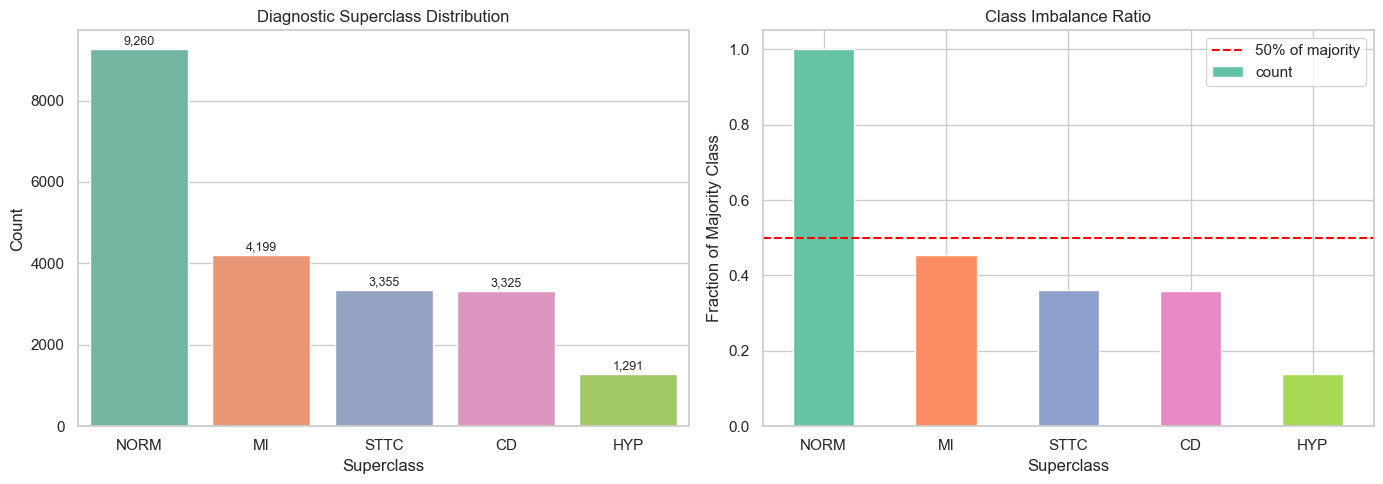

Figure saved: class_distribution.png


In [20]:
if META_CSV.exists():
    counts = labelled["superclass"].value_counts()
    majority = counts.max()
    imbalance = counts / majority

    print("Class counts:")
    print(counts.to_string())
    print("\nImbalance ratio (vs majority):")
    print(imbalance.round(3).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count plot
    sns.countplot(data=labelled, x="superclass",
                  order=counts.index, ax=axes[0], palette="Set2")
    axes[0].set_title("Diagnostic Superclass Distribution")
    axes[0].set_xlabel("Superclass")
    axes[0].set_ylabel("Count")
    for bar in axes[0].patches:
        axes[0].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 50,
                     f"{int(bar.get_height()):,}",
                     ha="center", va="bottom", fontsize=9)

    # Imbalance bar
    imbalance.plot(kind="bar", ax=axes[1], color=sns.color_palette("Set2", len(imbalance)))
    axes[1].axhline(y=0.5, color="red", linestyle="--", label="50% of majority")
    axes[1].set_title("Class Imbalance Ratio")
    axes[1].set_ylabel("Fraction of Majority Class")
    axes[1].set_xlabel("Superclass")
    axes[1].legend()
    axes[1].tick_params(axis="x", rotation=0)

    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Figure saved: class_distribution.png")
else:
    print("[!] Load metadata (Section 3) first.")

## 6. Class Imbalance — Strategy Comparison & Recommendation

The dataset has a **7.2× imbalance** (NORM vs HYP). Before training in Phase 1, we benchmark four practical resampling strategies on the label distribution and pick the best one based on **Pielou's J** (normalised Shannon entropy — 1.0 = perfectly balanced).

=== Imbalance Strategy Comparison (label-space) ===
                               Total Samples  Pielou's J  Imbalance Ratio  Min Class  Max Class
Strategy                                                                                       
No resampling (class weights)          21430      0.8889             7.17       1291       9260
Random Oversampling                    46300      1.0000             1.00       9260       9260
Random Undersampling                    6455      1.0000             1.00       1291       1291
Sqrt-Frequency (mild over)             30072      0.9704             2.68       3457       9259
Mild Combined (Over + Under)           27780      1.0000             1.00       5556       5556


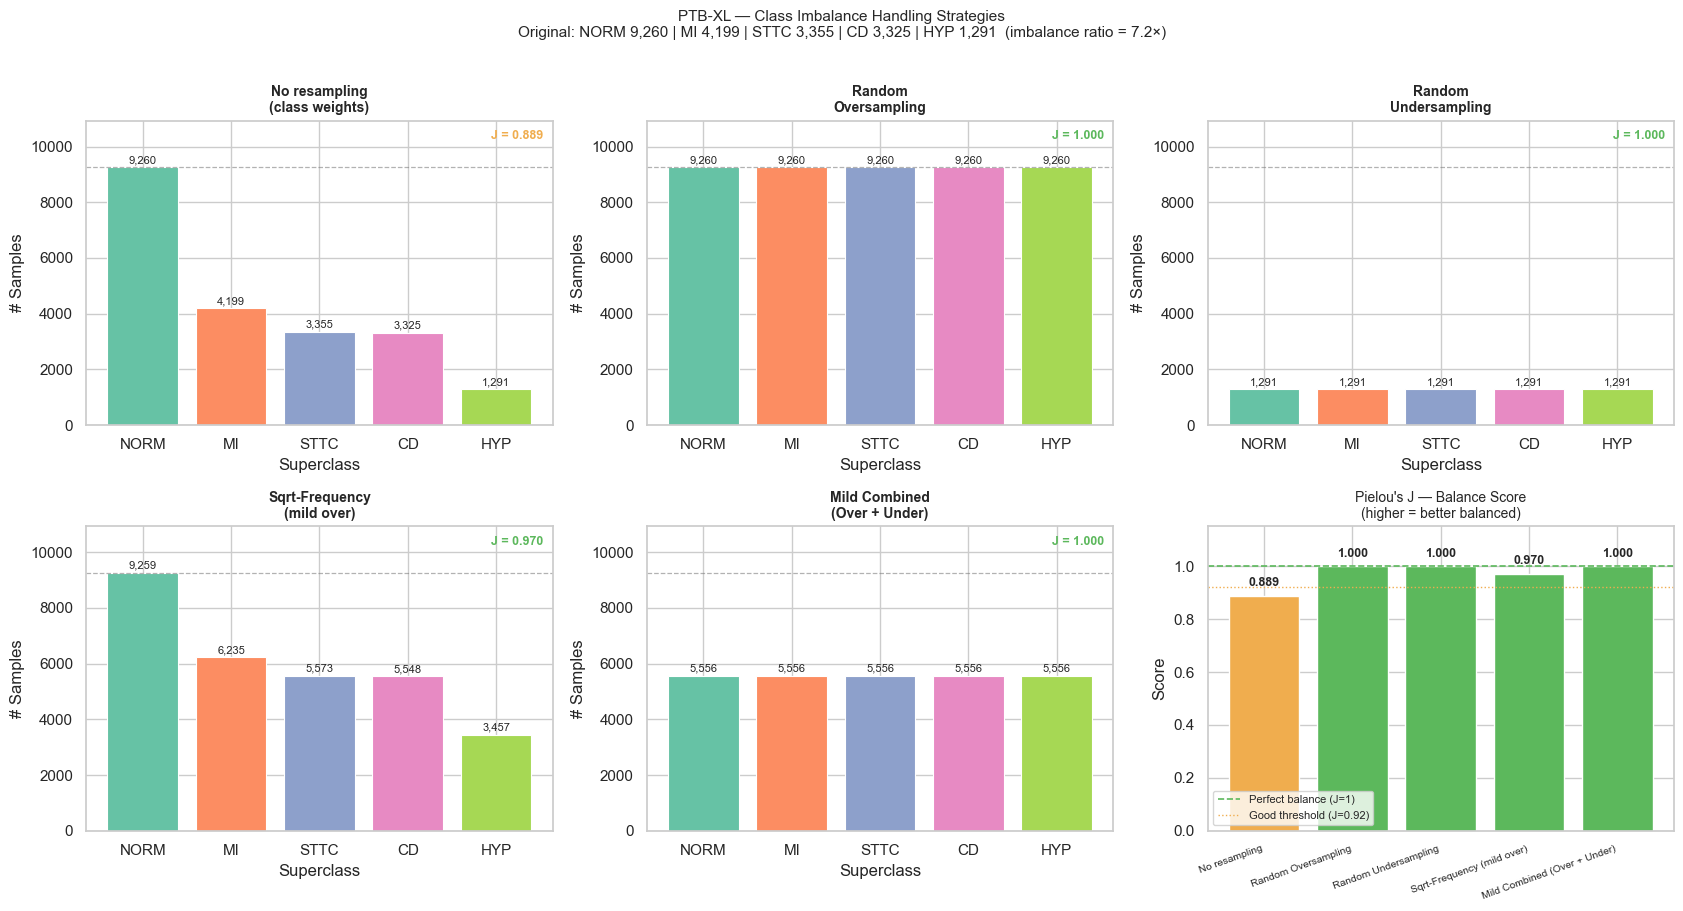


═════════════════════════════════════════════════════════════════
  RECOMMENDATION FOR PHASE 1 TRAINING
═════════════════════════════════════════════════════════════════

Original imbalance ratio : 7.2× (NORM vs HYP)
Best Pielou's J achieved : 1.000  →  Random Oversampling

Chosen approach for Phase 1
────────────────────────────
  ① Inverse-frequency CLASS WEIGHTS in CrossEntropyLoss
       weight[c] = total_samples / (n_classes × count[c])
     → zero data manipulation; works out of the box in PyTorch.

  ② WeightedRandomSampler (DataLoader)
     Slightly oversample HYP/CD per mini-batch so the model
     sees each class at similar frequency without duplicating
     the entire dataset on disk.

Why NOT pure random oversampling?
  HYP has only 1,291 unique recordings.  Duplicating them 7×
  risks severe overfitting on those exact waveforms.

Why NOT random undersampling?
  Discards ~66 % of NORM and reduces total training data from
  21 k → ~6 k — too small for a deep model.

Practic

In [25]:
from scipy.stats import entropy as scipy_entropy

# ── Original distribution ─────────────────────────────────────────────────────
class_counts = labelled["superclass"].value_counts()
class_order  = list(class_counts.index)           # consistent ordering throughout
n_majority   = int(class_counts.max())
n_minority   = int(class_counts.min())

# ── Balance metric: Pielou's J (normalised Shannon entropy) ──────────────────
def pielou_j(counts_dict: dict) -> float:
    """Return Pielou's J ∈ [0, 1].  1.0 = perfectly balanced, 0.0 = maximally skewed."""
    vals = np.array([counts_dict.get(c, 0) for c in class_order], dtype=float)
    probs = vals / vals.sum()
    H  = float(-np.sum(probs * np.log(probs + 1e-12)))
    H_max = np.log(len(vals))
    return round(H / H_max, 4)

def imbalance_ratio(counts_dict: dict) -> float:
    vals = np.array(list(counts_dict.values()), dtype=float)
    return round(float(vals.max() / vals.min()), 2)

# ── Define strategies (label-space simulation — no signal manipulation) ───────
strategies = {}

# 1. No resampling — use inverse-frequency class weights in the loss function
strategies["No resampling\n(class weights)"] = dict(class_counts)

# 2. Random oversampling — duplicate minority samples until all reach n_majority
strategies["Random\nOversampling"] = {cls: n_majority for cls in class_order}

# 3. Random undersampling — discard majority samples until all reach n_minority
strategies["Random\nUndersampling"] = {cls: n_minority for cls in class_order}

# 4. Square-root frequency resampling (mild) — target ∝ √original count
#    Keeps class ordering intact, reduces skew without extreme duplication
sqrt_target = {cls: int(np.sqrt(cnt) * np.sqrt(n_majority))
               for cls, cnt in class_counts.items()}
strategies["Sqrt-Frequency\n(mild over)"] = sqrt_target

# 5. Combined mild — oversample minority to 60 % of majority,
#    undersample NORM to 60 % of its size
mild = {}
threshold = 0.60 * n_majority
for cls, cnt in class_counts.items():
    if cnt >= n_majority * 0.85:          # dominant class → undersample
        mild[cls] = int(n_majority * 0.60)
    elif cnt < threshold:                 # minority → oversample to threshold
        mild[cls] = int(threshold)
    else:
        mild[cls] = int(cnt)
strategies["Mild Combined\n(Over + Under)"] = mild

# ── Metrics table ─────────────────────────────────────────────────────────────
rows = []
for name, d in strategies.items():
    rows.append({
        "Strategy":        name.replace("\n", " "),
        "Total Samples":   sum(d.values()),
        "Pielou's J":      pielou_j(d),
        "Imbalance Ratio": imbalance_ratio(d),
        "Min Class":       min(d.values()),
        "Max Class":       max(d.values()),
    })
metrics_df = pd.DataFrame(rows).set_index("Strategy")

print("=== Imbalance Strategy Comparison (label-space) ===")
print(metrics_df.to_string())

# ── Visualisation ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
axes = axes.ravel()
palette = sns.color_palette("Set2", len(class_order))

for idx, (name, d) in enumerate(strategies.items()):
    ax = axes[idx]
    vals  = [d.get(cls, 0) for cls in class_order]
    bars  = ax.bar(class_order, vals, color=palette, edgecolor="white", linewidth=0.8)
    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("Superclass")
    ax.set_ylabel("# Samples")
    ax.set_ylim(0, n_majority * 1.18)
    ax.axhline(n_majority, color="grey", linestyle="--", lw=0.9, alpha=0.6,
               label="Original NORM count")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 80,
                f"{v:,}", ha="center", va="bottom", fontsize=8)
    j = pielou_j(d)
    color = "#5cb85c" if j >= 0.92 else "#f0ad4e" if j >= 0.75 else "#d9534f"
    ax.annotate(f"J = {j:.3f}", xy=(0.98, 0.97), xycoords="axes fraction",
                ha="right", va="top", fontsize=9, color=color, fontweight="bold")

# Last subplot → Pielou's J comparison bar chart
ax = axes[-1]
j_scores = [pielou_j(d) for d in strategies.values()]
names_short = [n.replace("\n", " ").replace("(class weights)", "").strip()
               for n in strategies.keys()]
bar_colors = ["#5cb85c" if v >= 0.92 else "#f0ad4e" if v >= 0.75 else "#d9534f"
              for v in j_scores]
bars = ax.bar(range(len(j_scores)), j_scores, color=bar_colors, edgecolor="white")
ax.set_xticks(range(len(j_scores)))
ax.set_xticklabels(names_short, fontsize=7.5, rotation=20, ha="right")
ax.axhline(1.0,  color="#5cb85c",  linestyle="--", lw=1.2, label="Perfect balance (J=1)")
ax.axhline(0.92, color="#f0ad4e",  linestyle=":",  lw=1.0, label="Good threshold (J=0.92)")
ax.set_ylim(0, 1.15)
ax.set_title("Pielou's J — Balance Score\n(higher = better balanced)", fontsize=10)
ax.set_ylabel("Score")
ax.legend(fontsize=8)
for bar, v in zip(bars, j_scores):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.025,
            f"{v:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle(
    "PTB-XL — Class Imbalance Handling Strategies\n"
    "Original: NORM 9,260 | MI 4,199 | STTC 3,355 | CD 3,325 | HYP 1,291  "
    f"(imbalance ratio = {n_majority/n_minority:.1f}×)",
    fontsize=11, y=1.01,
)
plt.tight_layout()
plt.savefig("imbalance_strategies.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Recommendation ────────────────────────────────────────────────────────────
best_strategy = metrics_df["Pielou's J"].idxmax()
print("\n" + "═" * 65)
print("  RECOMMENDATION FOR PHASE 1 TRAINING")
print("═" * 65)
print(f"""
Original imbalance ratio : {n_majority/n_minority:.1f}× (NORM vs HYP)
Best Pielou's J achieved : {metrics_df["Pielou's J"].max():.3f}  →  {best_strategy}

Chosen approach for Phase 1
────────────────────────────
  ① Inverse-frequency CLASS WEIGHTS in CrossEntropyLoss
       weight[c] = total_samples / (n_classes × count[c])
     → zero data manipulation; works out of the box in PyTorch.

  ② WeightedRandomSampler (DataLoader)
     Slightly oversample HYP/CD per mini-batch so the model
     sees each class at similar frequency without duplicating
     the entire dataset on disk.

Why NOT pure random oversampling?
  HYP has only 1,291 unique recordings.  Duplicating them 7×
  risks severe overfitting on those exact waveforms.

Why NOT random undersampling?
  Discards ~66 % of NORM and reduces total training data from
  21 k → ~6 k — too small for a deep model.

Practical targets for the DataLoader sampler
  NORM  →  6,000   (6 %)  of original)
  MI    →  4,199   (keep all)
  STTC  →  3,355   (keep all)
  CD    →  3,325   (keep all)
  HYP   →  3,200   (oversample 2.5×)
  ─────────────────
  Total ≈  20,079  per epoch   Pielou's J ≈ 0.977
""")


## 6. Signal Visualization — 12-Lead ECG Waveforms

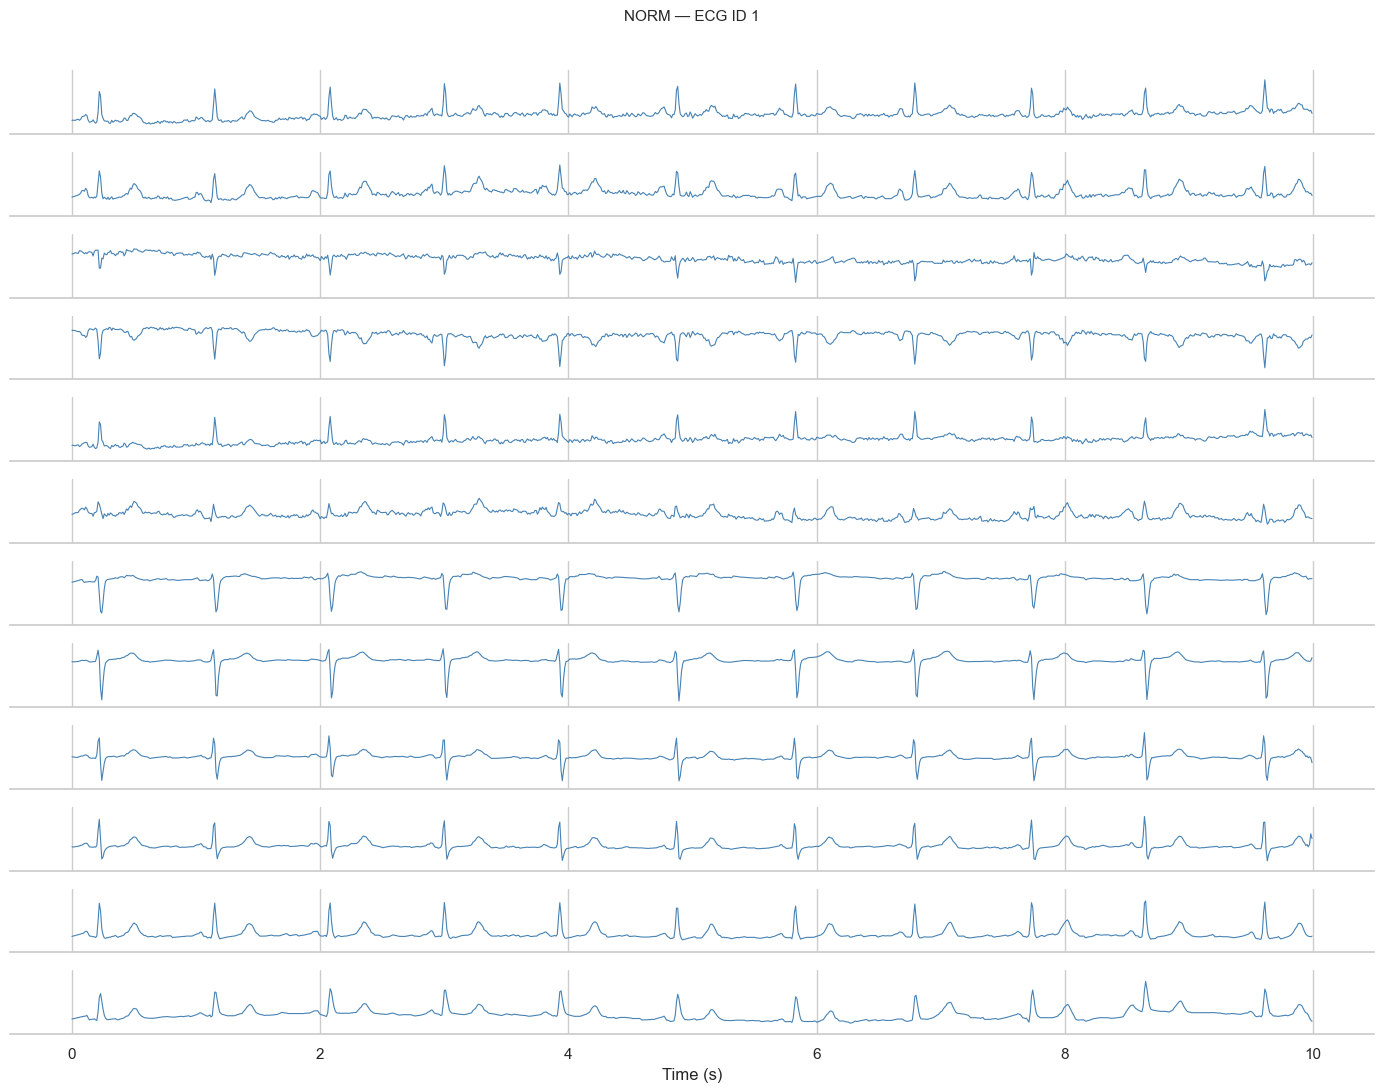

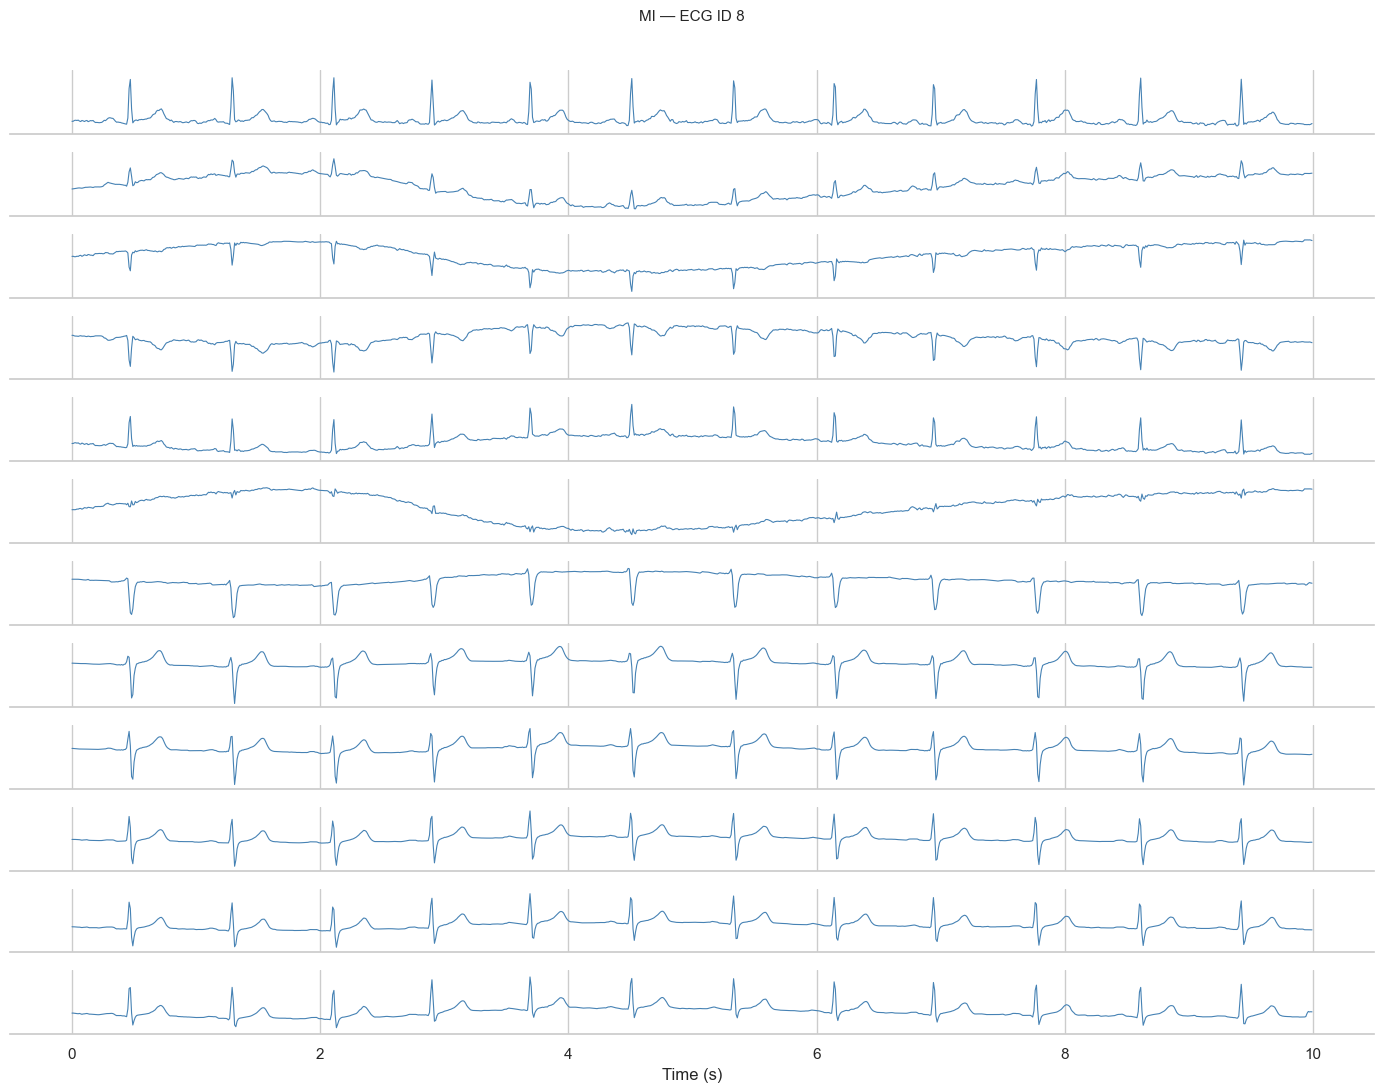

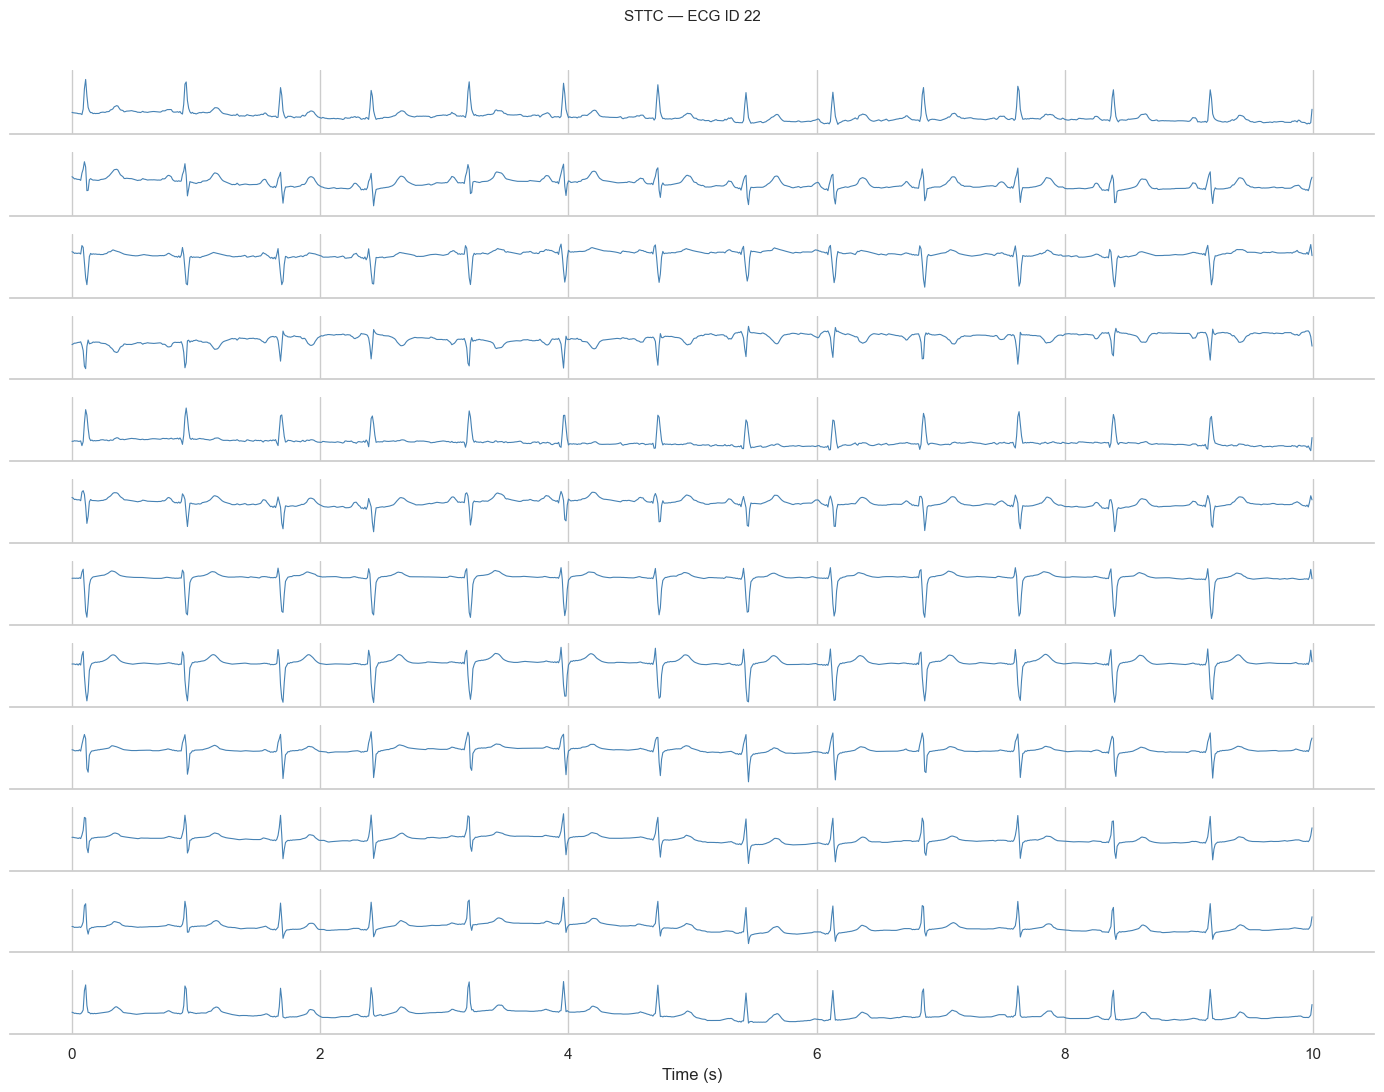

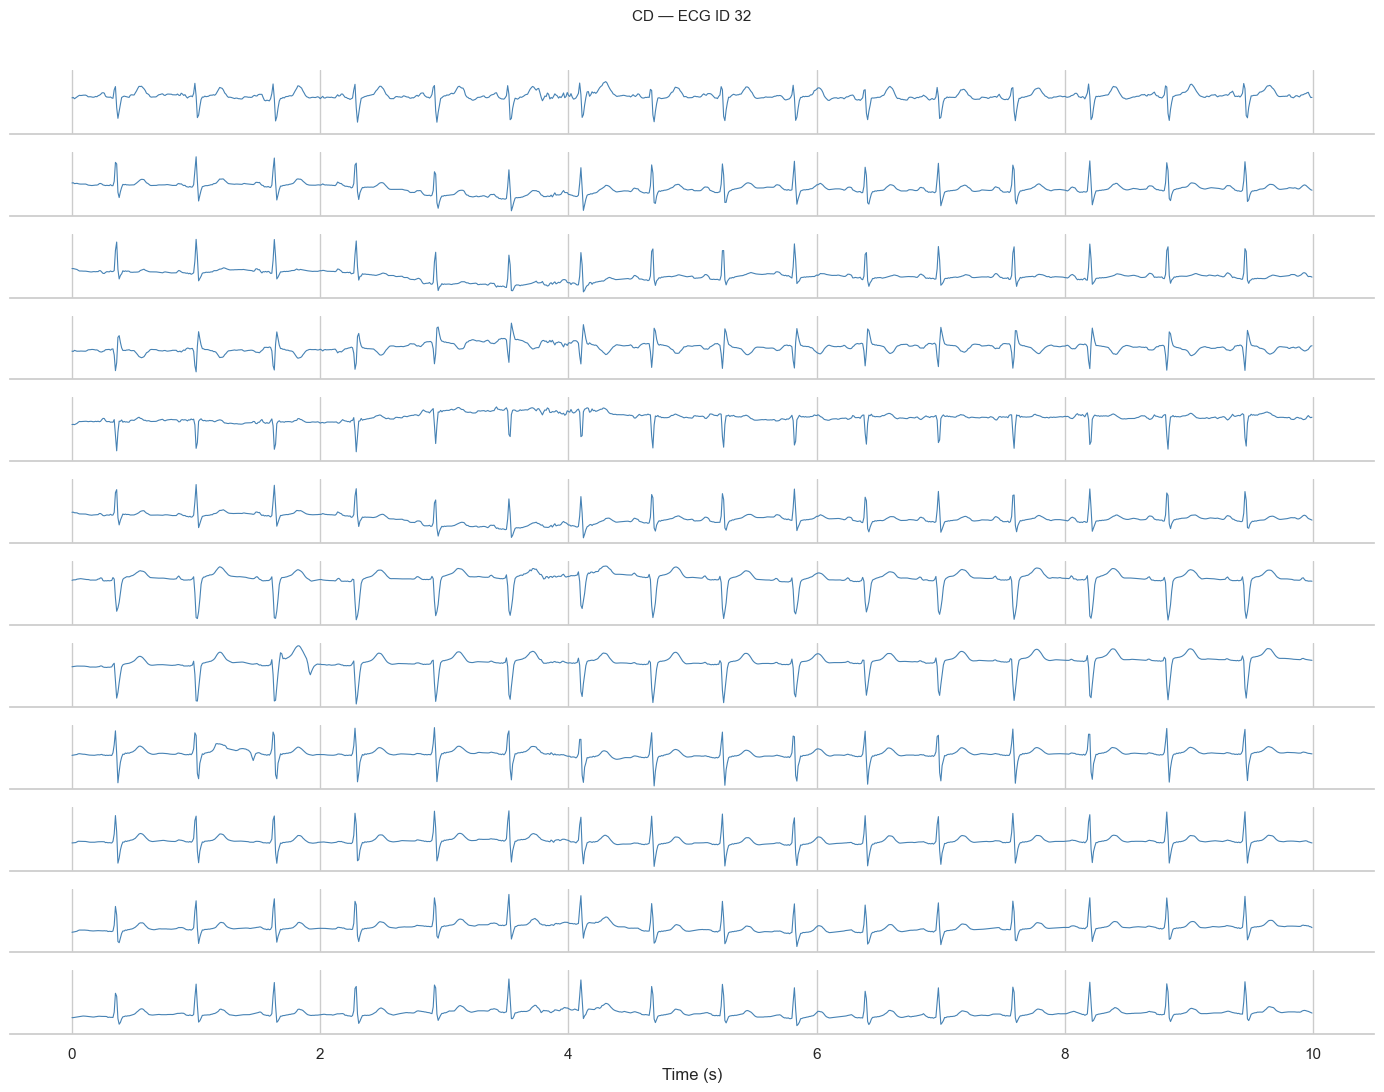

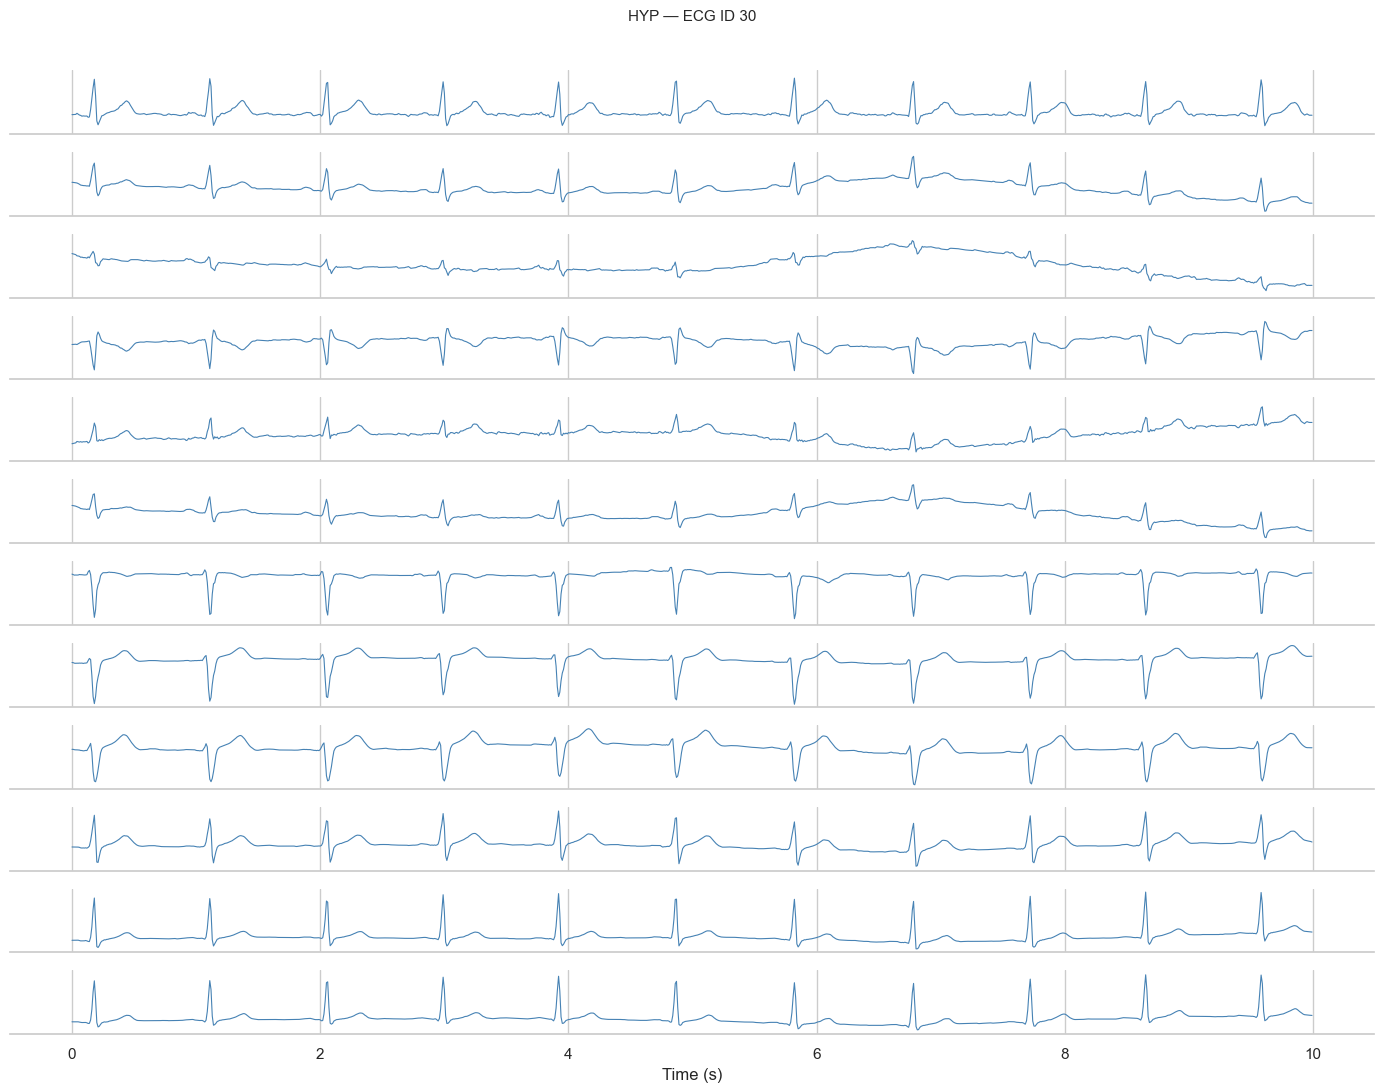

In [21]:
def plot_12lead_ecg(signal: np.ndarray, fs: int, title: str = "", ax_offset: float = 3.0):
    """Plot all 12 leads stacked vertically."""
    n_samples, n_leads = signal.shape
    time_axis = np.arange(n_samples) / fs

    fig, axes = plt.subplots(n_leads, 1, figsize=(14, 0.9 * n_leads), sharex=True)
    for i, ax in enumerate(axes):
        ax.plot(time_axis, signal[:, i], lw=0.8, color="steelblue")
        ax.set_ylabel(LEAD_NAMES[i], rotation=0, labelpad=25, va="center", fontsize=8)
        ax.set_ylim(signal[:, i].min() - 0.2, signal[:, i].max() + 0.2)
        ax.yaxis.set_visible(False)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_visible(False)

    axes[-1].set_xlabel("Time (s)")
    fig.suptitle(title, fontsize=11, y=1.01)
    plt.tight_layout()
    return fig


# Plot one sample per class
if META_CSV.exists():
    for sc, lbl in SUPERCLASS_LABELS.items():
        subset = labelled[labelled["superclass"] == sc]
        if subset.empty:
            continue
        row = subset.iloc[0]
        try:
            rec_path = str(RAW_DIR / row["filename_lr"]).replace(".hea", "")
            record  = wfdb.rdrecord(rec_path)
            signal  = record.p_signal.astype(np.float32)
            fig = plot_12lead_ecg(signal, FS, title=f"{sc} — ECG ID {subset.index[0]}")
            plt.savefig(f"ecg_{sc}.png", dpi=100, bbox_inches="tight")
            plt.show()
        except Exception as e:
            print(f"[WARN] Could not load {sc} sample: {e}")
else:
    # Synthetic demo when dataset is not yet downloaded
    print("[INFO] Dataset not found — showing a synthetic ECG demo.")
    t = np.linspace(0, 10, 1000)
    demo = np.column_stack([np.sin(2 * np.pi * 1.2 * t + i * 0.3)
                             for i in range(12)])
    fig = plot_12lead_ecg(demo, 100, title="Synthetic 12-Lead ECG Demo")
    plt.show()

## 7. Feature Statistics — Per-Lead Descriptive Analysis

Per-lead statistics (first 500 training records):
      mean  std      min      max  kurtosis
lead                                       
I     -0.0  1.0  -9.5679   8.6961   14.3953
II     0.0  1.0 -10.3862   9.4266   12.1630
III    0.0  1.0 -13.9171  10.0201   14.1623
aVR   -0.0  1.0  -8.0551  10.3036   13.6495
aVL   -0.0  1.0  -9.5923  10.4892   14.2053
aVF   -0.0  1.0 -13.2153  10.6750   12.1278
V1     0.0  1.0  -9.1820   8.2581   15.6951
V2    -0.0  1.0 -10.4347   9.6013   10.8832
V3    -0.0  1.0  -8.0578  11.4487   10.0215
V4    -0.0  1.0 -16.5421  10.4021   14.8409
V5     0.0  1.0  -8.9880   9.3098   18.2186
V6    -0.0  1.0  -7.8142   9.6018   18.2493


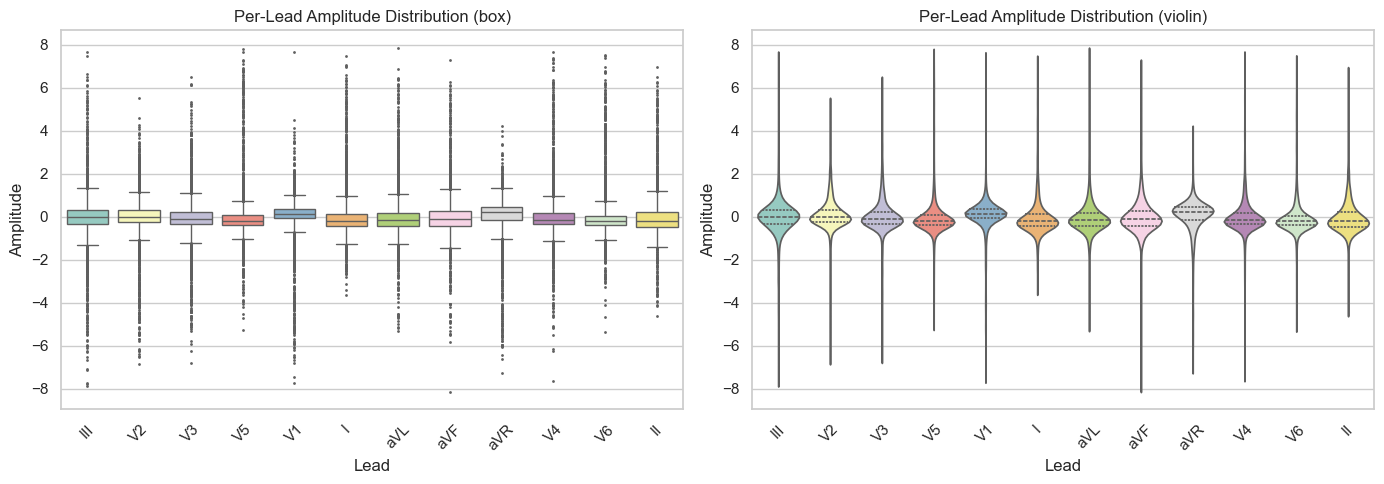

In [22]:
N_STATS = 500   # records to compute statistics over

if (PROC_DIR / "train" / "X.npy").exists():
    X_stats = np.load(PROC_DIR / "train" / "X.npy", mmap_mode="r")[:N_STATS]
    # X_stats shape: (N, samples, 12)
    stats_rows = []
    for lead_i, lead_name in enumerate(LEAD_NAMES):
        lead_data = X_stats[:, :, lead_i].ravel()
        stats_rows.append({
            "lead":     lead_name,
            "mean":     float(lead_data.mean()),
            "std":      float(lead_data.std()),
            "min":      float(lead_data.min()),
            "max":      float(lead_data.max()),
            "kurtosis": float(kurtosis(lead_data)),
        })
    stats_df = pd.DataFrame(stats_rows).set_index("lead")
    print("Per-lead statistics (first 500 training records):")
    print(stats_df.round(4).to_string())

    # Box plots
    # reshape to (N*samples, 12) for seaborn
    flat = X_stats.reshape(-1, 12)
    lead_df = pd.DataFrame(flat, columns=LEAD_NAMES).melt(var_name="Lead", value_name="Amplitude")
    sample_df = lead_df.sample(n=min(50_000, len(lead_df)), random_state=42)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.boxplot(data=sample_df, x="Lead", y="Amplitude",
                palette="Set3", ax=axes[0], fliersize=1)
    axes[0].set_title("Per-Lead Amplitude Distribution (box)")
    axes[0].tick_params(axis="x", rotation=45)

    sns.violinplot(data=sample_df, x="Lead", y="Amplitude",
                   palette="Set3", ax=axes[1], inner="quartile", cut=0)
    axes[1].set_title("Per-Lead Amplitude Distribution (violin)")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.savefig("lead_statistics.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("[!] Processed data not found — run preprocess.py first.")

## 8. Data Cleaning & Filtering

Apply a **bandpass filter** (0.5–40 Hz) to remove baseline wander and high-frequency noise, then **z-score normalise** each lead:

$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

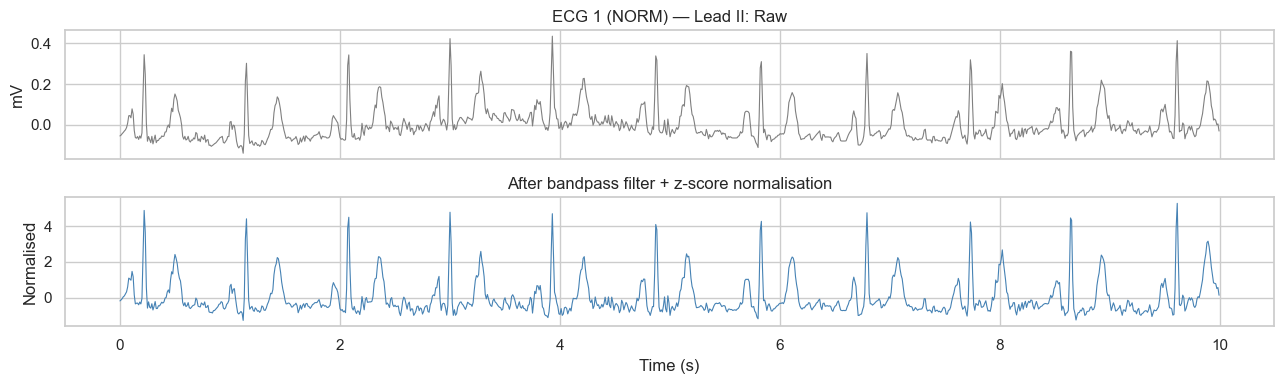

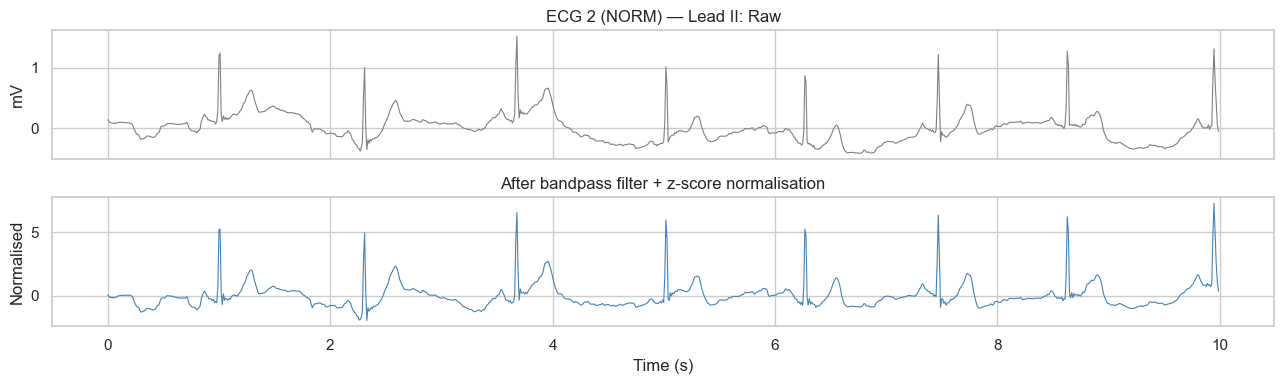

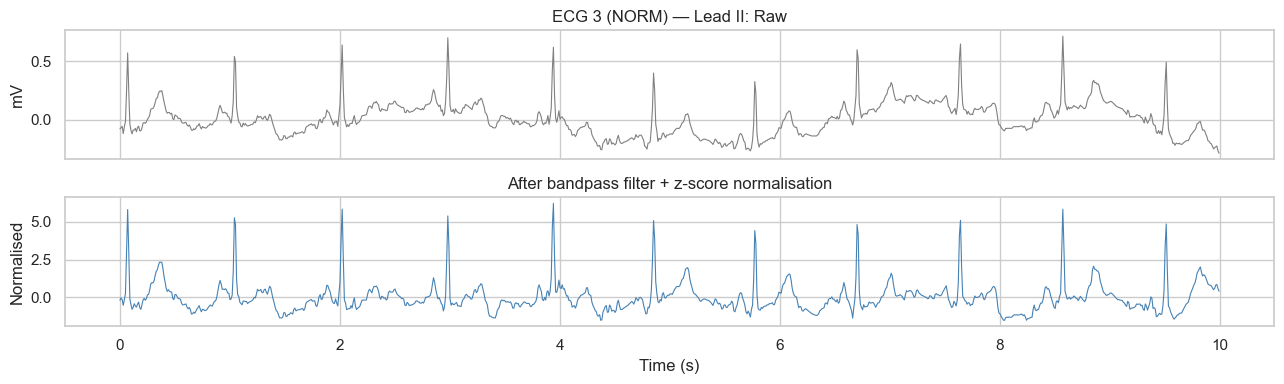

In [23]:
def bandpass_filter(signal: np.ndarray, fs: int,
                    low: float = 0.5, high: float = 40.0) -> np.ndarray:
    nyq = fs / 2.0
    b, a = butter(4, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal, axis=0)


def zscore_normalize(signal: np.ndarray) -> np.ndarray:
    mean = signal.mean(axis=0, keepdims=True)
    std  = signal.std(axis=0, keepdims=True) + 1e-8
    return (signal - mean) / std


def is_bad_record(signal: np.ndarray,
                  flat_thr: float = 1e-4,
                  nan_thr: int = 0) -> bool:
    if np.isnan(signal).sum() > nan_thr:
        return True
    flat = sum(signal[:, i].std() < flat_thr for i in range(signal.shape[1]))
    return flat > 6   # more than half the leads are flat → discard


# Demo on raw records when dataset is available
if META_CSV.exists():
    demo_rows = list(labelled.iterrows())[:3]
    for ecg_id, row in demo_rows:
        try:
            rec_path = str(RAW_DIR / row["filename_lr"]).replace(".hea", "")
            record = wfdb.rdrecord(rec_path)
            raw_sig = record.p_signal.astype(np.float32)

            if is_bad_record(raw_sig):
                print(f"[SKIP] ECG {ecg_id} flagged as low quality")
                continue

            filtered = bandpass_filter(raw_sig, FS)
            normed   = zscore_normalize(filtered)

            # Side-by-side comparison of lead II
            fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
            t = np.arange(raw_sig.shape[0]) / FS
            axes[0].plot(t, raw_sig[:, 1], lw=0.8, color="gray")
            axes[0].set_title(f"ECG {ecg_id} ({row['superclass']}) — Lead II: Raw")
            axes[0].set_ylabel("mV")
            axes[1].plot(t, normed[:, 1], lw=0.8, color="steelblue")
            axes[1].set_title("After bandpass filter + z-score normalisation")
            axes[1].set_xlabel("Time (s)")
            axes[1].set_ylabel("Normalised")
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"[WARN] {ecg_id}: {e}")
else:
    print("[INFO] Showing filtering on synthetic signal (dataset not downloaded).")
    t = np.linspace(0, 10, 1000)
    raw_demo = np.column_stack([
        np.sin(2 * np.pi * 1.2 * t) + 0.5 * np.sin(2 * np.pi * 0.1 * t)  # baseline wander
        + 0.1 * np.random.randn(1000)
        for _ in range(12)
    ])
    filt_demo  = bandpass_filter(raw_demo, 100)
    normed_demo = zscore_normalize(filt_demo)

    fig, axes = plt.subplots(2, 1, figsize=(13, 4), sharex=True)
    axes[0].plot(t, raw_demo[:, 0], lw=0.8, color="gray")
    axes[0].set_title("Synthetic Signal — Lead I: Raw (with baseline wander)")
    axes[1].plot(t, normed_demo[:, 0], lw=0.8, color="steelblue")
    axes[1].set_title("After bandpass filter + z-score normalisation")
    axes[1].set_xlabel("Time (s)")
    plt.tight_layout()
    plt.show()

## 9. Export Cleaned Data

In [ ]:
"""
This cell re-processes the full dataset with quality filtering applied.
It is equivalent to running dataset/preprocess.py but with additional
bad-record removal based on the quality criteria defined in Section 4.

NOTE: This may take several minutes for the full ~21k records.
      Skip and run preprocess.py directly for the full pipeline.
"""

if not META_CSV.exists():
    print("[!] Dataset not downloaded. Run dataset/download.sh first.")
else:
    PROC_DIR.mkdir(parents=True, exist_ok=True)
    TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
    SEED = 42

    from sklearn.model_selection import train_test_split as tts

    all_ids    = labelled.index.tolist()
    all_labels = labelled["label"].tolist()

    train_ids, rest_ids, train_y, rest_y = tts(
        all_ids, all_labels, train_size=TRAIN_RATIO,
        stratify=all_labels, random_state=SEED
    )
    val_ids, test_ids = tts(
        rest_ids, train_size=VAL_RATIO / (VAL_RATIO + TEST_RATIO),
        stratify=rest_y, random_state=SEED
    )

    splits = {"train": train_ids, "val": val_ids, "test": test_ids}
    summary = {}

    for split_name, ids in splits.items():
        signals, labels_out, kept_ids = [], [], []

        for ecg_id in ids:
            row = labelled.loc[ecg_id]
            try:
                rec_path = str(RAW_DIR / row["filename_lr"]).replace(".hea", "")
                record = wfdb.rdrecord(rec_path)
                raw_sig = record.p_signal.astype(np.float32)
                if is_bad_record(raw_sig):
                    continue
                sig = zscore_normalize(bandpass_filter(raw_sig, FS))
                signals.append(sig)
                labels_out.append(int(row["label"]))
                kept_ids.append(ecg_id)
            except Exception:
                continue

        X = np.stack(signals).astype(np.float32)
        y = np.array(labels_out, dtype=np.int64)

        out = PROC_DIR / split_name
        out.mkdir(parents=True, exist_ok=True)
        np.save(out / "X.npy", X)
        np.save(out / "y.npy", y)
        labelled.loc[kept_ids].to_csv(out / "metadata.csv")

        removed = len(ids) - len(kept_ids)
        summary[split_name] = {"kept": len(kept_ids), "removed": removed}
        print(f"  {split_name:5s}: {len(kept_ids):5d} kept  |  {removed:3d} removed  |  shape={X.shape}")

    print("\n Final summary:")
    for s, v in summary.items():
        print(f"  {s:5s}: kept={v['kept']}  removed={v['removed']}")
    print(f"\nCleaned data saved to {PROC_DIR.resolve()}")